# **Aurora Siger - Pre-Takeoff Analysis**
### **RM:** 570266
### **Name:** Renato Nascimento
### **GitHub Repository:** https://github.com/RenatoBrevi/Phase-01-Aurora-Siger-Operational-Report

## 1.1 Organização e descrição da telemetria

Interpretar dados referentes a:

Temperatura interna e externa;
Integridade estrutural (0/1);
Níveis de energia (%);
Pressão dos tanques;
Status dos módulos críticos.

In [1]:
# Importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reading csv file
df = pd.read_csv("telemetria_sintetica_500_linhas_abort.csv")

In [3]:
df.shape

(500, 16)

In [4]:
df.head(15)

,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min,launch_decision
0,2026-03-30T00:00:00,34.82,17.40,49.34,88.46,93.71,111.04,5.1341,9.58,2.19,110.77,1,1,1,81.15,READY
1,2026-03-30T00:01:00,21.59,28.00,51.26,51.47,86.22,95.83,4.2353,23.29,4.75,108.24,1,1,1,78.29,READY
2,2026-03-30T00:02:00,27.54,4.20,49.51,109.78,75.98,88.77,3.3393,24.95,5.06,99.55,1,1,1,51.36,READY
3,2026-03-30T00:03:00,19.86,16.96,50.75,62.22,62.54,95.26,3.0235,24.92,5.17,143.55,0,1,1,161.21,ABORT
4,2026-03-30T00:04:00,29.56,-0.99,51.31,95.09,90.74,93.61,4.3584,10.87,2.95,95.16,1,1,1,142.48,READY
5,2026-03-30T00:05:00,30.23,29.02,50.57,70.77,64.26,105.01,3.4124,21.83,5.05,104.95,1,1,1,95.48,READY
6,2026-03-30T00:06:00,20.75,28.37,51.53,111.85,83.96,99.54,4.3066,7.24,4.18,144.27,1,1,1,153.91,READY
7,2026-03-30T00:07:00,22.07,3.43,49.40,27.88,89.28,112.64,4.9679,24.56,5.20,101.29,1,1,1,134.07,READY
8,2026-03-30T00:08:00,34.10,0.78,49.17,80.66,98.57,117.16,5.6784,20.11,6.14,130.65,1,1,1,98.86,READY
9,2026-03-30T00:09:00,29.42,8.07,51.40,65.15,69.92,82.56,2.9671,5.42,5.32,124.42,1,1,1,45.97,READY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    str    
 1   internal_temp_c          500 non-null    float64
 2   external_temp_c          500 non-null    float64
 3   battery_voltage_v        500 non-null    float64
 4   battery_current_a        500 non-null    float64
 5   battery_soc_percent      500 non-null    float64
 6   battery_capacity_ah      500 non-null    float64
 7   energy_available_kwh     500 non-null    float64
 8   power_load_kw            500 non-null    float64
 9   energy_loss_percent      500 non-null    float64
 10  tank_pressure_bar        500 non-null    float64
 11  structural_integrity     500 non-null    int64  
 12  critical_modules_status  500 non-null    int64  
 13  telemetry_link_status    500 non-null    int64  
 14  estimated_autonomy_min   500 non-null

In [6]:
# See what we got only in 'ABORT'
abortion = df[df["launch_decision"] == "ABORT"]
print(abortion)

               timestamp  internal_temp_c  external_temp_c  battery_voltage_v  \
3    2026-03-30T00:03:00            19.86            16.96              50.75   
12   2026-03-30T00:12:00            18.92            17.87              49.88   
13   2026-03-30T00:13:00            36.16             3.74              51.54   
15   2026-03-30T00:15:00            34.27            29.84              49.33   
16   2026-03-30T00:16:00            18.85            11.69              51.52   
..                   ...              ...              ...                ...   
483  2026-03-30T08:03:00            16.58             2.07              46.56   
486  2026-03-30T08:06:00            12.68             5.93              51.35   
490  2026-03-30T08:10:00            19.34            27.30              50.59   
494  2026-03-30T08:14:00            26.20            -2.69              47.25   
496  2026-03-30T08:16:00            19.85            23.49              50.63   

     battery_current_a  bat

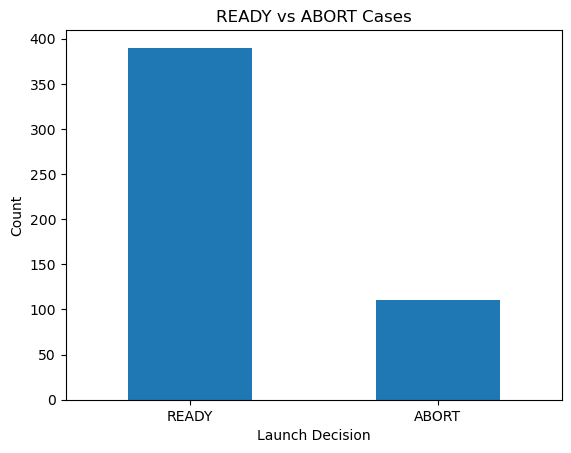

In [7]:
decision_counts = df["launch_decision"].value_counts()

decision_counts.plot(kind="bar")
plt.title("READY vs ABORT Cases")
plt.xlabel("Launch Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

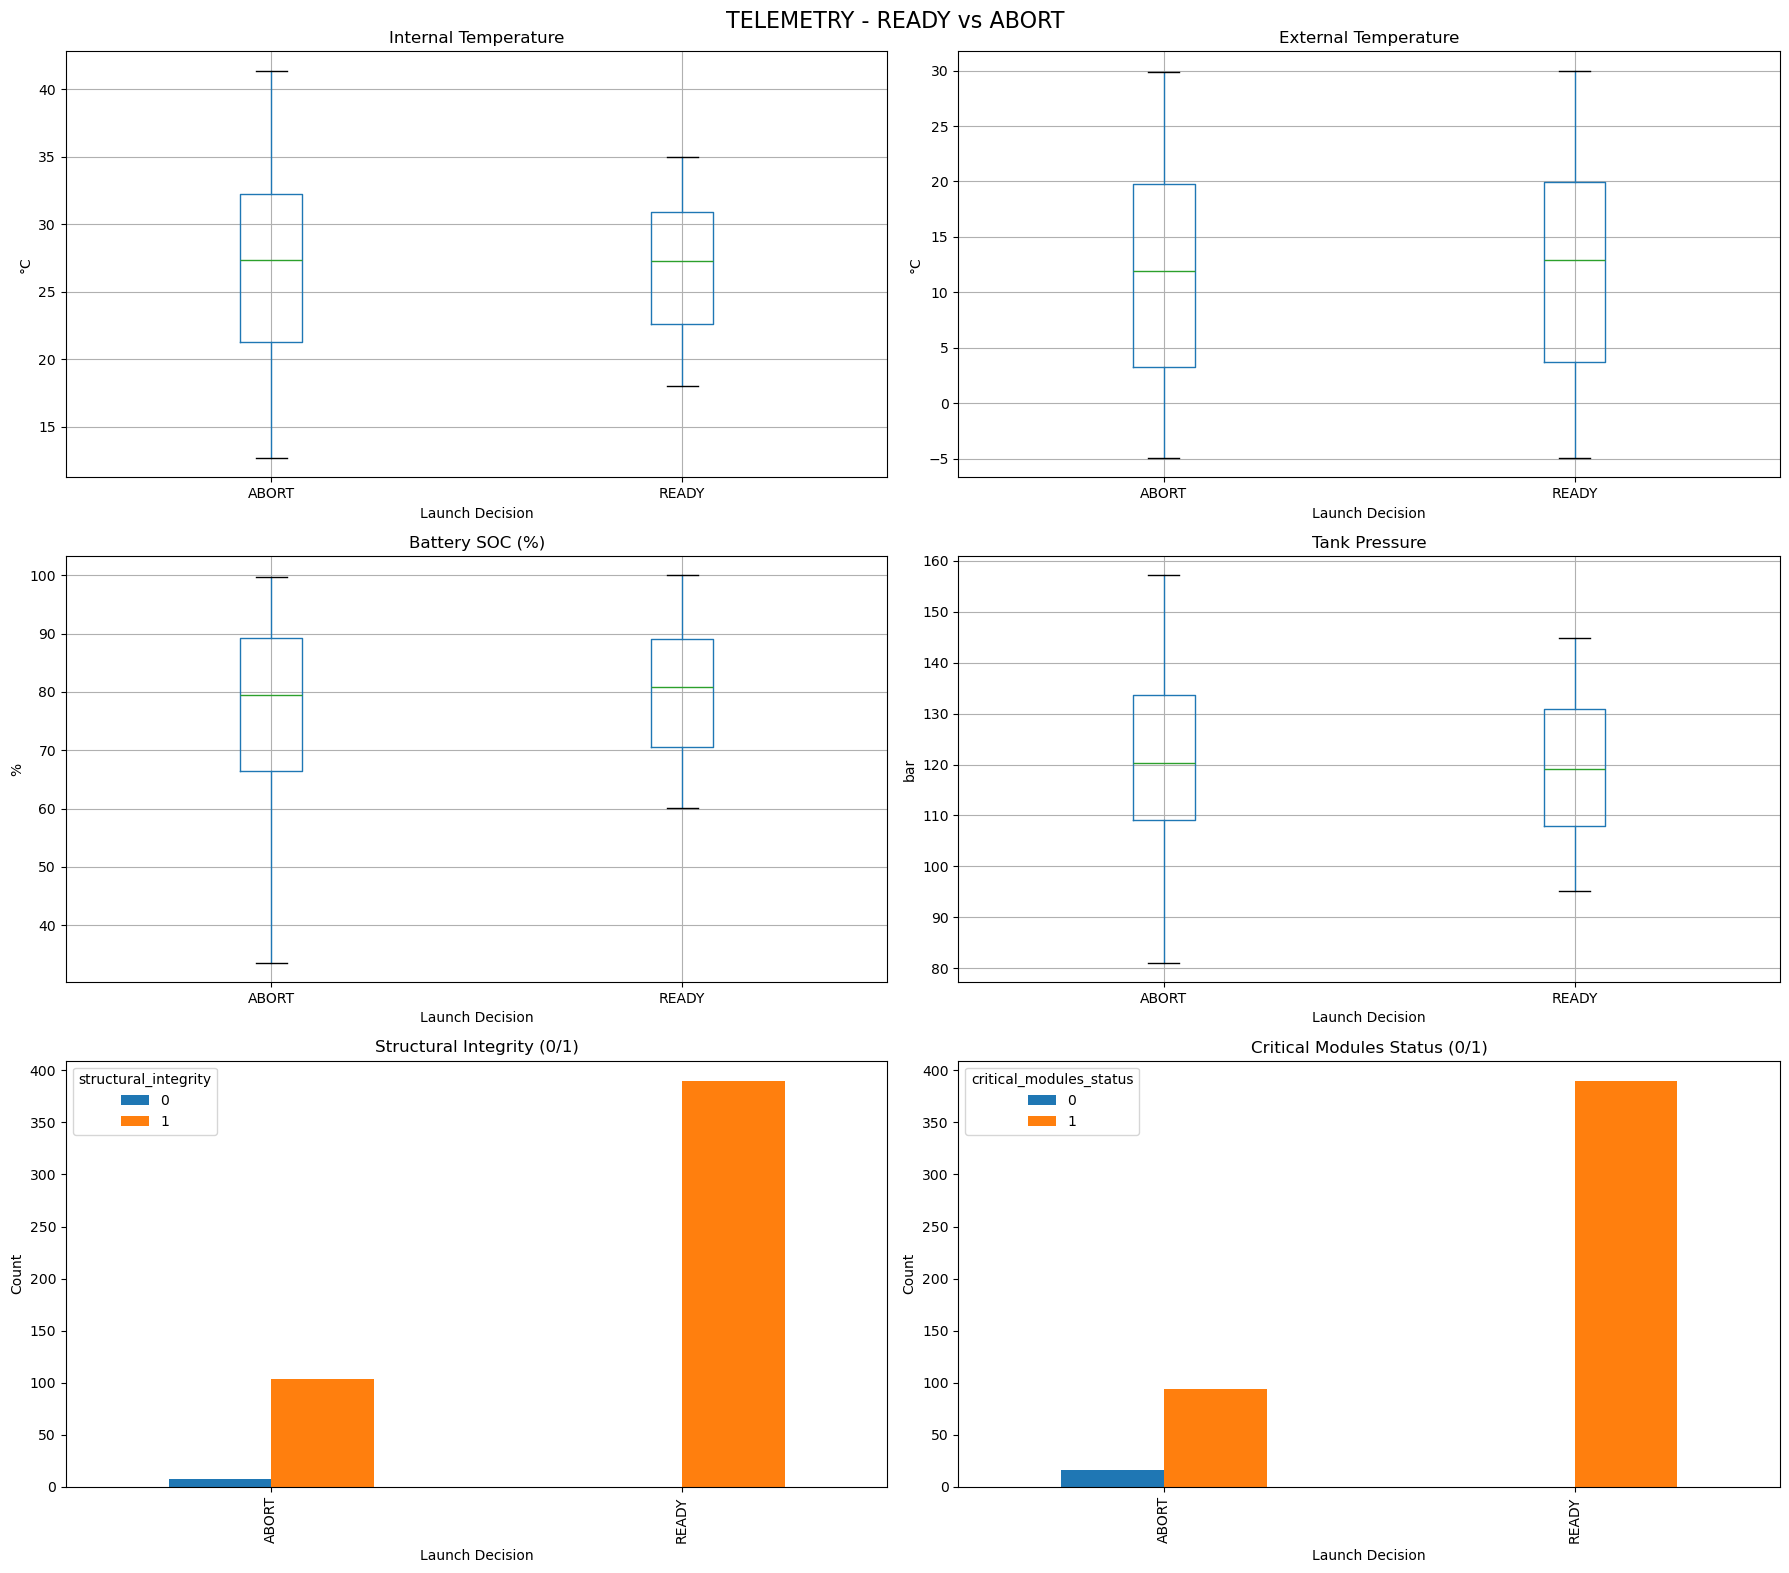

In [8]:
# Make the column is sBytesWarning
df["launch_decision"] = df["launch_decision"].astype(str)

# Creating a fugire with variable graphics
fig, axes = plt.subplots(3, 2, figsize=(18,16))
fig.suptitle("Telemetry: READY vs ABORT", fontsize=16)

# Internal Temperature
df.boxplot(column="internal_temp_c", by="launch_decision", ax=axes[0, 0]) # setting up as the frist graph
axes[0, 0].set_title("Internal Temperature")
axes[0, 0].set_xlabel("Launch Decision")
axes[0, 0].set_ylabel("°C")

# External Temperature
df.boxplot(column="external_temp_c", by="launch_decision", ax=axes[0, 1]) # setting up as the second graph
axes[0, 1].set_title("External Temperature")
axes[0, 1].set_xlabel("Launch Decision")
axes[0, 1].set_ylabel("°C")

# Energy Level from Battery (%)
df.boxplot(column="battery_soc_percent", by="launch_decision", ax=axes[1, 0]) # setting up as the third graph
axes[1, 0].set_title("Battery SOC (%)")
axes[1, 0].set_xlabel("Launch Decision")
axes[1, 0].set_ylabel("%")

# Tank Pressure 
df.boxplot(column="tank_pressure_bar", by="launch_decision", ax=axes[1, 1]) # setting up as the fourth graph
axes[1, 1].set_title("Tank Pressure")
axes[1, 1].set_xlabel("Launch Decision")
axes[1, 1].set_ylabel("bar")

# Sctruture Integrity
struct_counts = df.groupby(["launch_decision", "structural_integrity"]).size().unstack(fill_value=0)
struct_counts.plot(kind="bar", ax=axes[2,0]) #setting up as the fifth graph
axes[2, 0].set_title("Structural Integrity (0/1)")
axes[2, 0].set_xlabel("Launch Decision")
axes[2, 0].set_ylabel("Count")
axes[2, 0].legend(title="structural_integrity")

# Critical Module Status 
critical_counts = df.groupby(["launch_decision", "critical_modules_status"]).size().unstack(fill_value=0)
critical_counts.plot(kind="bar", ax=axes[2 , 1]) #setting up as the sixth graph
axes[2 , 1].set_title("Critical Modules Status (0/1)")
axes[2 , 1].set_xlabel("Launch Decision")
axes[2 , 1].set_ylabel("Count")
axes[2 , 1].legend(title="critical_modules_status")

# Removing pandas auto titles
plt.suptitle("TELEMETRY - READY vs ABORT", fontsize=16)
plt.tight_layout()
plt.show()

## **INTERPRETANTO OS DADOS**

### **[BR]** 

### Não foi splotado os outliers para termos uma visão mais geral

**Internal Temperature (Temperatura Interna)** - A temperatura interna tanto quando a nave está em modo "READY" como em modo "ABORT" tem uma distribuição parecida embora o "ABORT" tenha os bigodes muito maiores na parte de baixo do gráfico, o que mostra maior variação em relação ao "READY". As medianas estão bem próximas. Portanto a temperatura interna não se mostra como o agente causador para os casos de aborto, mesmo apresentado casos maiores de variação na parte de baixo. 

**External Temperature (Temperatura Externa)** = A temperatura externa apresenta medianas próximas e bigodes (whiskers) iguais, mostrando que tanto o "READY" como o "ABORT" têm bastante variações. A temperatura externa não está mostrando grande impacto entre "READY" e "ABORT".

**Structural Integrity (Integridade Estrutural)** - Todos os casos de "ABORT" se mostrando quando a integridade estrutural da nave estava em 0, já que é um fator decisivo para o mal funcionamento da nave. Ainda assim, uma quantidade significativa de abortos se deram enquanto a integridade estrutural da nave se encontrava em boas condições.

**Battery SOC (Níveis de Energia)** - Os níveis de energia estão com mediana similares entre os casos de "ABORT" e "READY". Quando os níveis de energia estão baixos as chances de ter aborto são grandes, mostrando muita variação com níveis baixos de bateria. Porém, ainda assim acontecem abortos com níveis de bateria altos.

**Tank Pressure (Pressão dos Tanques)** - Novamente o "ABORT" e "READY" estão com mediana similar, porém com variações grandes tanto com o tanque quase vazio, como com o tanque cheio.

**Critical Modules Status (Status dos Módulos Críticos)** - Como no "Structural Integrity" todos os casos onde o resultado foi 0 houve "ABORT" imediato, pois é uma variante essencial estar em bom funcionamento. Os casos abortados pelo resultado 0 foram superiores ao "Structural Integrity", o que aponta falhas maiores nos módulos críticos, necessitando de mais ateção. 

**Breve Conclusão** - Não existe neste caso um dado certeiro que faça com que sempre se obtenha o resultado "ABORT" com maior frequência em determinado tipo de operação, mas sim em cada parcela dos dados podendo resultar em "ABORT" se um único dado funcionar errado. Seguindo pela taxa de sucesso de quase 82% onde a nave não apresenta falhas para poder decolar, acredito que deve-se solucionar melhores abordagens para que essa taxa de "acerto" seja elevada para não correr o risco de explosão e perdas, já que vidas humanas estão em risco.

In [9]:
ready = 500
abort = 110

total = ready + abort


ready_percent = (ready / total) * 100
abort_percent = (abort / total) * 100

print(f"READY: {ready_percent:.2f}%")
print(f"ABORT: {abort_percent:.2f}%")

READY: 81.97%
ABORT: 18.03%


## 1.2 Algoritmo de verificação

Construir um algoritmo (fluxograma/pseudocódigo) capaz de decidir: “PRONTO PARA DECOLAR” ou “DECOLAGEM ABORTADA” com base em faixas seguras predefinidas.

In [10]:
# Fluxograma / pseudocodigo
"""
Inicío
    Funcao decisao_lancamento(linha)
        se linha.structural_integrity = 0 entao
            retorne "ABORT - Structural Failure"
        senao se linha.critical_modules_status = 0 entao
            retorne "ABORT - Critical Modules Failure" 
        senao se linha.telemetry_link_status = 0 entao
            retorne "ABORT - Telemetry Link Failure" 
        senao se linha.battery_soc_percent < 60 entao
            retorne "ABORT - Low Battery
        senao se linha.tank_pressure_bar < 95 ou linha.tank_pressure_bar > 145 entao
            retorne "ABORT - Unsafe Tank Pressure
        senao se linha.internal_temp_c < 18 ou linha.internal_temp_c > 35 entao
            retorne "ABORT - Unsafe Internal Temperature"%%!
        senao se linha.external_temp_c < -5 ou linha.external_temp_c > 30 entao
            retorne "ABORT - Unsafe External Temperature" 
        senao
            retorne "READY TO LAUNCH"
        FIM SE

    fim funcao

    para cada linha no dataframe faca
        linha.nova_decisao_lancamento = decisao_lancamento(linha)
    fim para

    exibir as 30 primeiras linhas com:
        timestamp,
        structural_integrity, 
        critical_modules_status, 
        telemetry_link_status, 
        battery_soc_percent, 
        tank_pressure_bar, 
        internal_temp_c,
        external_temp_c, 
        launch_decision,
        new_launch_decision

fim
""" 

'\nInicío\n    Funcao decisao_lancamento(linha)\n        se linha.structural_integrity = 0 entao\n            retorne "ABORT - Structural Failure"\n        senao se linha.critical_modules_status = 0 entao\n            retorne "ABORT - Critical Modules Failure" \n        senao se linha.telemetry_link_status = 0 entao\n            retorne "ABORT - Telemetry Link Failure" \n        senao se linha.battery_soc_percent < 60 entao\n            retorne "ABORT - Low Battery\n        senao se linha.tank_pressure_bar < 95 ou linha.tank_pressure_bar > 145 entao\n            retorne "ABORT - Unsafe Tank Pressure\n        senao se linha.internal_temp_c < 18 ou linha.internal_temp_c > 35 entao\n            retorne "ABORT - Unsafe Internal Temperature"%%!\n        senao se linha.external_temp_c < -5 ou linha.external_temp_c > 30 entao\n            retorne "ABORT - Unsafe External Temperature" \n        senao\n            retorne "READY TO LAUNCH"\n        FIM SE\n\n    fim funcao\n\n    para cada linh

## 1.3 Script em Python

Implementar a lógica do algoritmo em Python, simulando:

Leitura dos dados;
Execução das verificações;
Resultado final impresso.

In [11]:
# Decision function 
def launch_decision(row):
    if row["structural_integrity"] == 0:
        return "ABORT - Structural Failure" # Naming the failure make more readable
    elif row["critical_modules_status"] == 0:
        return "ABORT - Critical Modules Failure"# Naming the failure make more readable
    elif row["telemetry_link_status"] == 0:
        return "ABORT - Telemetry Link Failure"# Naming the failure make more readable
    elif row["battery_soc_percent"] < 60:
        return "ABORT - Low Battery"# Naming the failure make more readable
    elif row["tank_pressure_bar"] < 95 or row["tank_pressure_bar"] > 145:
        return "ABORT - Unsafe Tank Pressure"# Naming the failure make more readable
    elif row["internal_temp_c"] < 18 or row["internal_temp_c"] > 35:
        return "ABORT - Unsafe Internal Temperature"# Naming the failure make more readable
    elif row["external_temp_c"] < -5 or row["external_temp_c"] > 30:
        return "ABORT - Unsafe External Temperature"# Naming the failure make more readable
    else:
        return "READY TO LAUNCH"

# Applying new row with decisions
df["new_launch_decision"] = df.apply(launch_decision, axis=1)

# Printing every status 
print(df[[
    "timestamp",
    "structural_integrity", 
    "critical_modules_status", 
    "telemetry_link_status", 
    "battery_soc_percent", 
    "tank_pressure_bar", 
    "internal_temp_c",
    "external_temp_c", 
    "launch_decision",
    "new_launch_decision" #This new roll make the difference to read what's going on
]].head(30))

              timestamp  structural_integrity  critical_modules_status  \
0   2026-03-30T00:00:00                     1                        1   
1   2026-03-30T00:01:00                     1                        1   
2   2026-03-30T00:02:00                     1                        1   
3   2026-03-30T00:03:00                     0                        1   
4   2026-03-30T00:04:00                     1                        1   
5   2026-03-30T00:05:00                     1                        1   
6   2026-03-30T00:06:00                     1                        1   
7   2026-03-30T00:07:00                     1                        1   
8   2026-03-30T00:08:00                     1                        1   
9   2026-03-30T00:09:00                     1                        1   
10  2026-03-30T00:10:00                     1                        1   
11  2026-03-30T00:11:00                     1                        1   
12  2026-03-30T00:12:00               

## 1.4 Análise energética

Calcular autonomia inicial considerando:

Capacidade total (kwh);
Carga atual (%);
Consumo estimado na decolagem;
Perdas energéticas.

In [12]:
# Capacidade total da bateria em (kWh) - O máximo de energia que o sistema pode armazenar
df["full_capacity_kwh"] = (df["battery_voltage_v"] * df["battery_capacity_ah"]) / 1000

# Carga atual da bateria em (%) - A fração da capacidade total que está disponível no momento da leitura
df["current_energy_kwh"] = df["full_capacity_kwh"] * (df["battery_soc_percent"] / 100)

# Consumo estimado na decolagem em (kW) - Potência exigida durante a operação, representada pela carga do sistema 
df["useful_energy_kwh"] = df["current_energy_kwh"] * (1 - df["energy_loss_percent"] / 100)

# Perdas energéticas em (%) - Parcela de energia que não será efetivamente aproveitada devido a ineficiências operacinais
df["initial_autonomy_h"] = df["useful_energy_kwh"] / df["power_load_kw"] # Autonomia inicial em horas
df["initial_autonomy_m"] = df["initial_autonomy_h"] * 60 # Autonomia inicial em minutos

# Printing the result 
print(df[[
    "timestamp",
    "full_capacity_kwh", 
    "battery_soc_percent", 
    "power_load_kw", 
    "energy_loss_percent",
    "useful_energy_kwh", 
    "initial_autonomy_m"
]].head(10))

             timestamp  full_capacity_kwh  battery_soc_percent  power_load_kw  \
0  2026-03-30T00:00:00           5.478714                93.71           9.58   
1  2026-03-30T00:01:00           4.912246                86.22          23.29   
2  2026-03-30T00:02:00           4.395003                75.98          24.95   
3  2026-03-30T00:03:00           4.834445                62.54          24.92   
4  2026-03-30T00:04:00           4.803129                90.74          10.87   
5  2026-03-30T00:05:00           5.310356                64.26          21.83   
6  2026-03-30T00:06:00           5.129296                83.96           7.24   
7  2026-03-30T00:07:00           5.564416                89.28          24.56   
8  2026-03-30T00:08:00           5.760757                98.57          20.11   
9  2026-03-30T00:09:00           4.243584                69.92           5.42   

   energy_loss_percent  useful_energy_kwh  initial_autonomy_m  
0                 2.19           5.021666   

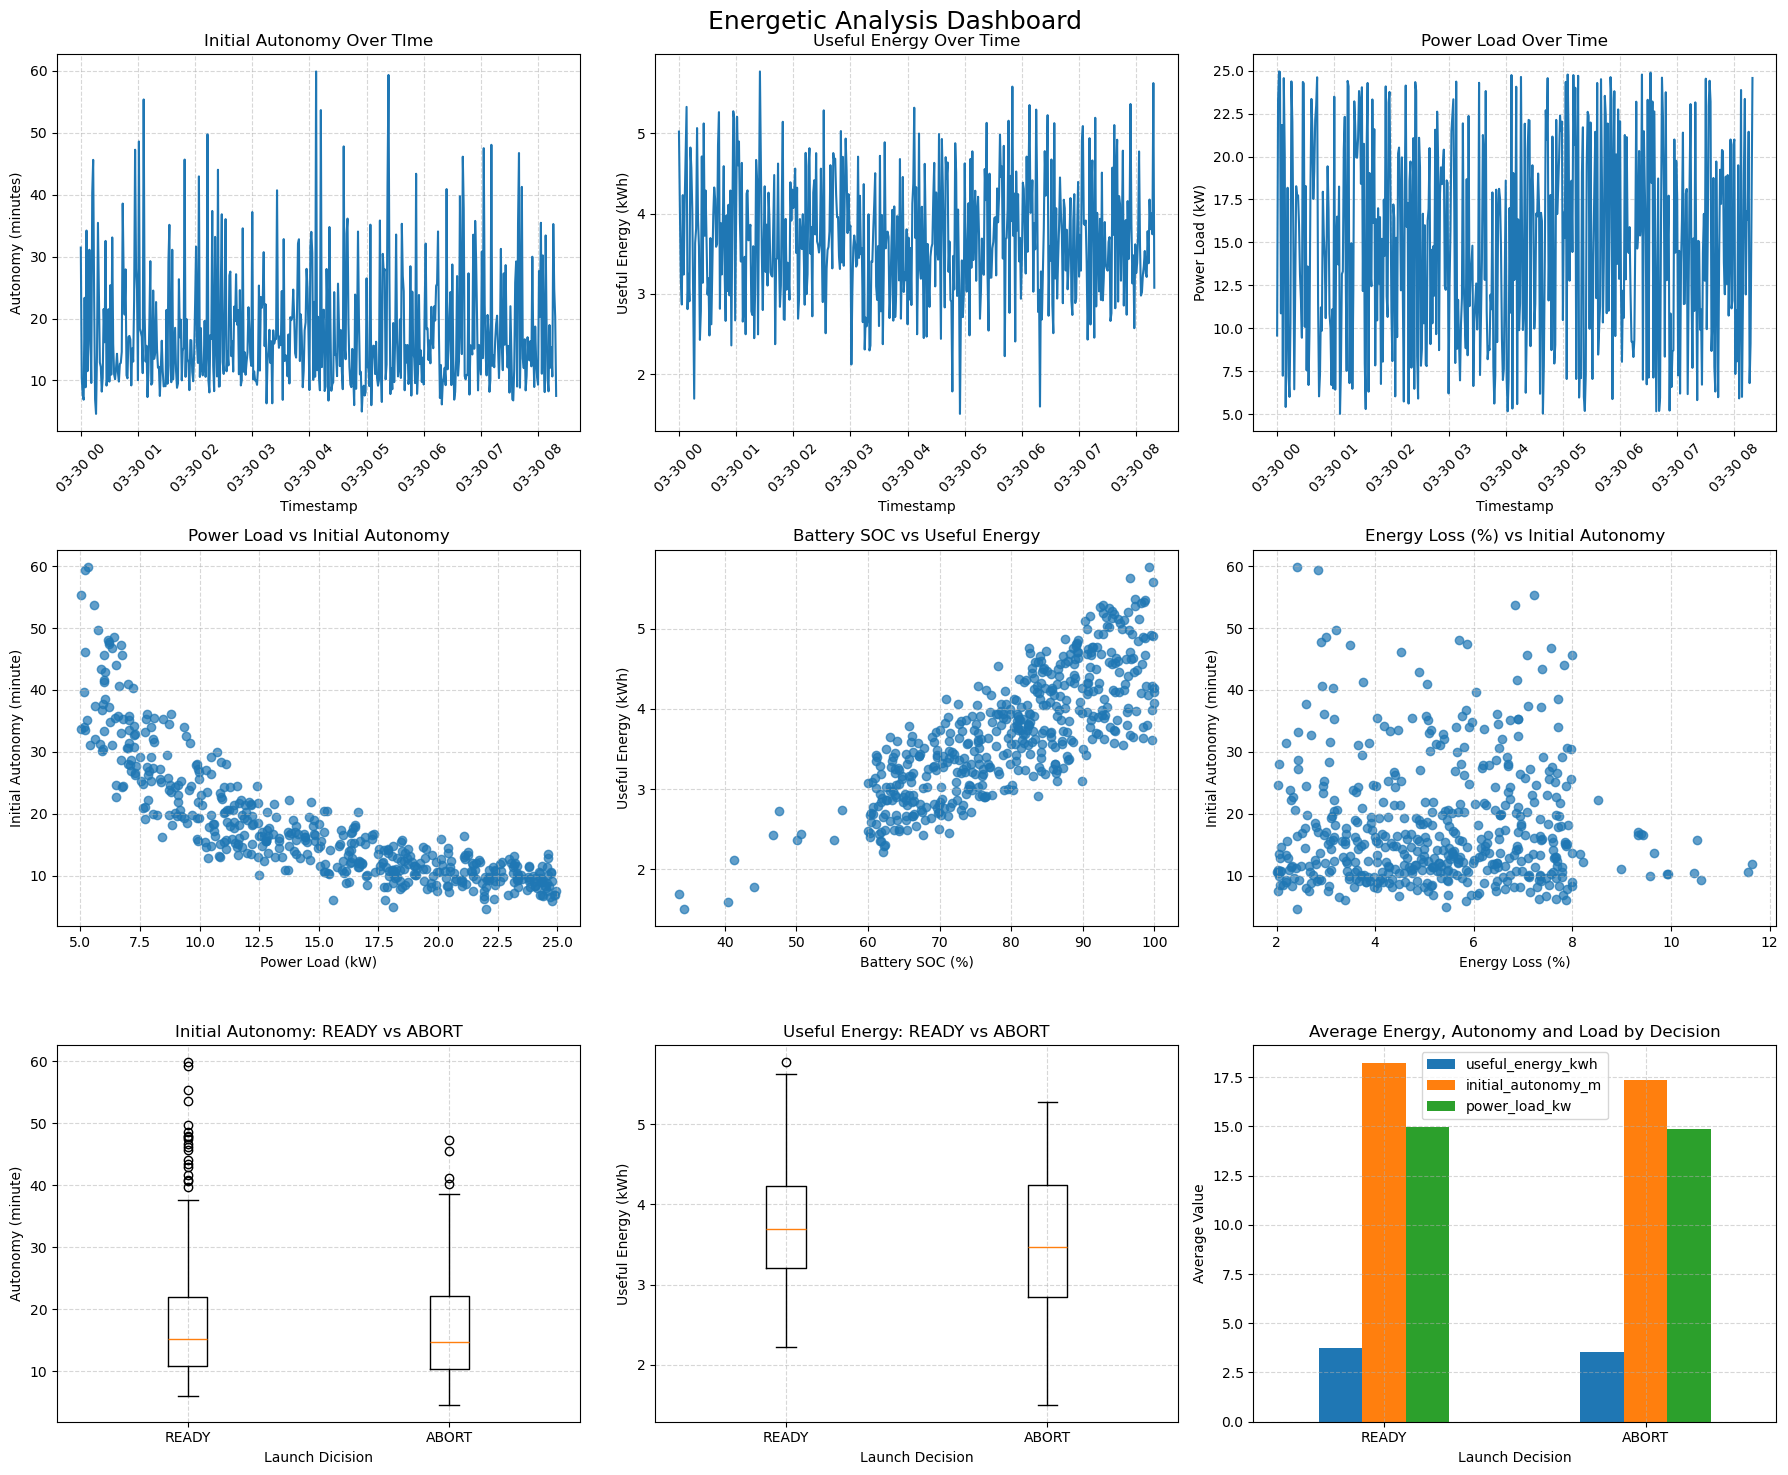

In [17]:
# Changing timestamp from string (str) to datetime type
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["launch_decision"] = df["launch_decision"].astype(str)

# Extracting ready and abort from "launch_decision" to use on plot
ready_df = df[df["launch_decision"] == "READY"] 
abort_df = df[df["launch_decision"] == "ABORT"] 

# Creating 3x3 panel
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Energetic Analysis Dashboard", fontsize=18)

# PLOT - Autonomy over time 
axes[0, 0].plot(df["timestamp"], df["initial_autonomy_m"])
axes[0, 0].set_title("Initial Autonomy Over TIme")
axes[0, 0].set_xlabel("Timestamp")
axes[0, 0].set_ylabel("Autonomy (minutes)")
axes[0, 0].tick_params(axis="x", rotation=45)

# PLOT - Useful energy over time 
axes[0, 1].plot(df["timestamp"], df["useful_energy_kwh"])
axes[0, 1].set_title("Useful Energy Over Time")
axes[0, 1].set_xlabel("Timestamp")
axes[0, 1].set_ylabel("Useful Energy (kWh)")
axes[0, 1].tick_params(axis="x", rotation=45)

# PLOT - Consumption over time 
axes[0, 2].plot(df["timestamp"], df["power_load_kw"])
axes[0, 2].set_title("Power Load Over Time")
axes[0, 2].set_xlabel("Timestamp")
axes[0, 2].set_ylabel("Power Load (kW)")
axes[0, 2].tick_params(axis="x", rotation=45)

# SCATTER - consumption vs autonomy 
axes[1, 0].scatter(df["power_load_kw"], df["initial_autonomy_m"], alpha=0.7)
axes[1, 0].set_title("Power Load vs Initial Autonomy")
axes[1, 0].set_xlabel("Power Load (kW)")
axes[1, 0].set_ylabel("Initial Autonomy (minute)")

# SCATTER - SOC Battery vs Useful Energy 
axes[1, 1].scatter(df["battery_soc_percent"], df["useful_energy_kwh"], alpha=0.7)
axes[1, 1].set_title("Battery SOC vs Useful Energy")
axes[1, 1].set_xlabel("Battery SOC (%)")
axes[1, 1].set_ylabel("Useful Energy (kWh)")

# SCATTER - Losses vs Autonomy
axes[1, 2].scatter(df["energy_loss_percent"], df["initial_autonomy_m"], alpha=0.7)
axes[1, 2].set_title("Energy Loss (%) vs Initial Autonomy")
axes[1, 2].set_xlabel("Energy Loss (%)")
axes[1, 2].set_ylabel("Initial Autonomy (minute)")

# BOXPLOT - Autonomy - READY vs ABORT 
axes[2, 0].boxplot(
    [ready_df["initial_autonomy_m"], abort_df["initial_autonomy_m"]],
    tick_labels=["READY", "ABORT"]
)
axes[2, 0].set_title("Initial Autonomy: READY vs ABORT")
axes[2, 0].set_xlabel("Launch Dicision")
axes[2, 0].set_ylabel("Autonomy (minute)")

# BOXPLOT - Useful Energy - READY vs ABORT
axes[2, 1].boxplot(
    [ready_df["useful_energy_kwh"], abort_df["useful_energy_kwh"]],
    tick_labels=["READY", "ABORT"]
)
axes[2, 1].set_title("Useful Energy: READY vs ABORT")
axes[2, 1].set_xlabel("Launch Decision")
axes[2, 1].set_ylabel("Useful Energy (kWh)")

# PLOT - means by decision 
decision_means = df.groupby("launch_decision")[[
    "useful_energy_kwh",
    "initial_autonomy_m", 
    "power_load_kw"
]].mean()

# Reindex label
decision_means = decision_means.reindex(["READY", "ABORT"])

decision_means.plot(kind="bar", ax=axes[2, 2])
axes[2, 2].set_title("Average Energy, Autonomy and Load by Decision")
axes[2, 2].set_xlabel("Launch Decision")
axes[2, 2].set_ylabel("Average Value")
axes[2, 2].tick_params(axis="x", rotation=0)


# GRID and transparency 
for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## ANÁLISE ENERGÉTICA

**Initial Autonomy Over Time (Autonomia Inicial ao longo do tempo):** O gráfico mostra uma autonomia inicial variando ao longo do tempo de forma consistente. Essa oscilação é causada provavelmente pela combinação de energia útil disponível, carga de bateria, perdas energéticas e o consumo de energia. 

**Useful Energy Over time (Energia útil ao longo do tempo):** A energia útil também oscila dentro de uma faixa estável como a autonomia inicial. A energia útil se mantém relativamente estável ao longo do tempo mesmo com a flutuação moderada.

**Power Load Over Time (Carga de energia ao longo do tempo):** A carga de energia oscila bastante, impactando de forma direta na autonomia. 

**Power Load vs Initial Autonomy (Carga de Potência vs Autonomia Inicial):** Quanto maior a carga de energia (power_load_kw), menor será a autonomia inicial (initial_autonomy_m). As pequenas cargas de energia geram autonomias bem maiores, já as cargas altas acabam comprimindo a autonomia. 

**Battery SOC vs Useful Energy (Bateria vs Energia Útil):** Quanto maior a porcentagem de energia armazenada (battery_soc_percent) maior será a quantidade de energia útil (useful_energy_kwh). É o que se espera dessa relação entre energia útil e bateria. O SOC é um excelente indicador para reserva energética da nave. Embora a energia final e aproveitável dependa da capacidade total e de perdas operacionais. A dispersão de energia útil pode ocorrer pela tensão da bateria, capacidade de Ah e de perdas energéticas.

**Energy Loss vs Initial Autonomy (Perda Energética vs Autonomia Inicial):** Podemos ver a tendência de uma perda energética maior associada a menor autonomia. Podemos ver de forma negativa, porém menos intensa e mais dispersa em relação entre Carga de Potência vs Autonomia Inicial. 

**Initial Autonomy: READY vs ABORT (Autonomia Inicial):** A mediana em "READY" é ligeiramente maior em relação ao "ABORT" e podemos ver muitas sobreposições entre os grupos. A autonomia inicial sozinha não explica o peso da decisão final no lançamento da nave.

**Useful Energy: READY vs ABORT (Energia útil):** Neste caso a energia útil também se aproximam entre os casos de "READY" e "ABORT" na mediana, embora a "READY" também seja um pouco maior em relação ao "ABORT". A energia útil não explica o motivo de "ABORT" como critério isolado. 

**Average Energy, Autonomy and Load by Decision (Energia Média, Autonomia e Carga por Decisão):** "READY" mostra uma média um pouco maior de Energia Útil e Autonomia, já a Carga de Potência é bem parecido entre "READY" e "ABORT". Olhando para o gráfico, vemos uma diferença tão pequena, que quase não enxergamos. 

**Breve Conclusão:** A análise energética mostra que a autonomia inicial do sistema é influênciada pela potência consumida na operação, apresentando uma relação inversa entre carga e tempo disponível de funcionamento. Obeservou-se a correlação positiva entre o estado de carga da bateria e a energia útil, confirmando que maiores nívels de Bateria (SOC) aumentam a reserva energética de forma efetiva. Na relação entre perdas energéticas e autonomia mostrou-se mais difusa, indicando uma influ~encia secundária. Na comparação entre "READY" e "ABORT", os casos prontos para lançamento apresentam médias ligeiramente superiores de energia útil e autonomia, porém com for sobreposição entre os grupos. Isso sugere que, embora o estado enérgetico contribua para a viabilidade operacional, ele não é suficiente para medir isoladamente, para explicar a decisão final, que parece depende de forma mais decisiva de variáveis críticas de segurança do sistema. 

## 1.5 Análise assistida por IA

Solicitar à IA: 

Classificação dos dados;
Identificação de possíveis anomalias;
Sugestões de risco.

## **1. Classificação dos Dados**
Os dados de telemetria podem ser classificados em três grupos principais:

### **a) Variáveis númericas contínuas** 
São as variáveis que medem o estado físico e energético do sistema em escala contínua: 
- internal_temp_c
- external_temp_c
- battery_voltage_v
- battery_current_a
- battery_soc_percent
- baterry_capacity_ah
- energy_available_kwh
- power_load_kw
- energy_loss_percent
- tank_pressure_bar
- estimated_autonomy_min
Essas variáveis permitem analisar desempenho, consumo, autonomia e condições operacionais.

### **b) Variáveis binárias**
São indicadores de estado crítico, com valor 0 ou 1: 
- structural_integrity
- critical_modules_status
- telemetry_link_status
Nelas, o valor 1 representa condição normal, enquanto 0 representa falha ou comprometimento.

### **c) Variável categórica de decisão**
A coluna:
- launch_decision
funciona como variável de classificação final do sistema, separando os registros em:
- READY
- ABORT

### **Interpretação da classificação** 
A classificação operacional do dataset mostra que a decisão final não depende de uma única variável isolada, mas da combinação entre: 
- condições energéticas,
- condições ambientais,
- integridade estrutural,
- funcionamento dos módulos críticos,
- estabilidade do link de telemetria.
Na prática, os dados indicam que as variáveis binárias de segurança têm maior peso na decisão final do que pequenas oscilações das variáveis contínuas.

## **2. Identificação de possíveis anomalias** 
Com base na lógica usada para decisão de lançamento, as principais anomalias observáveis ou detectáveis no conjunto de dados são: 

### **a) Falhas críticas explícitas**
São as anomalias mais graves, pois levam diretamente ao ABORT: 
- structural_integrity = 0
- critical_modules_status = 0
- telemetry_link_status = 0
Esses casos representam falhas de segurança, integridade ou comunicação, e têm forte associação com abortos.

### **b) Valores fora das faixas seguras**
Também podem ser tratados como anomalias operacionais: 
- battery_soc_percent < 60
- tank_pressure_bar < 95 ou > 145
- internal_temp_c < 18 ou > 35
- external_temp_c < -5 ou > 30
Esses registros indicam condição fora do envelope operacional esperado.

### **c) Anomalias energéticas**
Mesmo quando não há falha crítica explícita, alguns comportamentos merecem atenção: 
- autonomia inicial muito baixa;
- energia útil reduzida em relação ao SOC (Batteria);
- carga de potência muito alta para o mível de energia disponível;
- perdas energéticas elevadas associadas a queda acentuada da autonomia.

### **d) Inconsistências entre variáveis**
Também podem ser consideradas anomalias: 
- energia útil relativamente alta com autonomia muito baixa;
- SOC (bateria) elevado, mas autonomia reduzida por excesso de carga;
- registro com valores energéticos aparentemente adequados, mas classificado como "ABORT" por falha estrutural ou de telemetria.

### **Leitura analítica**
Os gráficos sugerem que as anomalias mais importantes não estão apenas nos valores extremos das variáveis numéricas, mas principlamente nas falhas dos indicadores binários. Já as varia´veis energéticas mostram influência clara sobre autonomia e desempenho, mas não explicam sozinhas a ocorrência de abortos.

## **3. Sugestão de risco**
Com base no comportamento dos dados, os principais riscos operacionais são: 

### **a) Risco estrutural**
Quando structural_integrity = 0, há compromentimento direto da segurança do sistema. Esse é um dos riscos mais críticos, pois inviabiliza a operação mesmo que os demais parâmetros estejam dentro da faixa normal.

### **b) Risco de falha em módulos críticos**
Quando critical_modules_status = 0, o sistema pode perder funções essenciais para uma operação segura. Esse tipo de falha tende a ter impacto imediato na decisão de aborto.

### **c) Risco de falha em módulos críticos**
Quando telemetry_link_status = 0, o sistema perde capacidade de monitoramenteo e controle remoto. Mesmo que a condição física pareça adequada, a ausência de telemtria representa alto risco operacional.

### **d) Risco energético**
Mesmo não sendo o principal fator isolado de "ABORT", o estado energético merece atenção: 
- SOC (bateria) baixo reduz margem de segurança;
- perdas energéticas altas diminuem a energia útil;
- carga de potência elevada derruba a autonomia rapidamente
Os gráficos mostram com clareque que:
- maior power_load_kw reduz a autonomia;
- maior battery_soc_percent aumenta a energia útil;
- perdas energéticas elevadas tendem a prejudicar o tempo operacional.

### **e) Risco térmico e de pressão**
Temperaturas e pressão fora da faixa segura indicam risco de instabilidade: 
- superaquecimento interno pode comprometer componentes;
- temperatura externa extrema pode afetar desempenho;
- pressão inadequada pode indicar risco mecânico e operacional.

## **Conclusão Geral** 
A análise indica que os dados de telemetria podem ser classsificados de forma clara entre variáveis contínuas, variáveis binárias e decisão final de lançamento. As anomalias mais relevantes concentram-se em falhas críticas de integridade, módulos e telemetria, além de valores fora das faixas seguras de operação. Em relação aos riscos, observa-se que o sistema é mais sensível às falhas binárias de segurança do que a pequenas variações energéticas, embora energia, autonomia, perdas e carga tenham papel importante no desempenho operacional. Assim, a decisão "ABORT" parece ser motivada principalmente por riscos críticops de segurança, enquanto as variáveis energéticas funcionam como fatores complementares de viabilidade.

## 1.6 Reflexão crítica

Texto sobre: 

Ética e responsabilidade;
Impacto social da exploração espacial;
Sustentabilidade tecnológica.